In [1]:
import warnings
from dataclasses import dataclass
from typing import Optional, Sequence, Tuple

import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table

from astroquery.vizier import Vizier
from astroquery.mast import Observations
from astroquery.eso import Eso

/home/felipe/miniconda3/envs/DAHAD/lib/python3.12/site-packages/requests/__init__.py:109: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(


In [2]:
def _to_coord(ra, dec) -> SkyCoord:
	"""
	Convert RA/Dec in degrees to SkyCoord.
	"""
	return SkyCoord(ra=float(ra) * u.deg, dec=float(dec) * u.deg, frame="icrs")


def _safe_len(table) -> int:
	"""
	Safely get table length.
	"""
	if table is None:
		return 0
	return len(table)


def _table_to_pandas(table: Optional[Table]) -> Optional[pd.DataFrame]:
	"""
	Convert Astropy Table to pandas, handling empty tables.
	"""
	if table is None or len(table) == 0:
		return None
	return table.to_pandas()

In [3]:
def query_vizier_catalogs(
	ra,
	dec,
	radius_arcsec: float = 2.0,
	catalogs: Optional[dict] = None,
	row_limit: int = -1,
) -> Tuple[pd.DataFrame, dict]:
	"""
	Query several VizieR catalogs around one coordinate.

	Parameters
	----------
	ra, dec : float
		Coordinates in degrees.

	radius_arcsec : float, optional
		Search radius in arcsec.

	catalogs : dict, optional
		Dictionary mapping readable survey names to VizieR catalog IDs.

	row_limit : int, optional
		VizieR row limit. Use -1 for no limit.

	Returns
	-------
	summary : pandas.DataFrame
		One row per catalog with match status.

	raw_results : dict
		Dictionary with raw Astropy tables.
	"""
	if catalogs is None:
		catalogs = {
			"Gaia_DR3": "I/355/gaiadr3",
			"2MASS": "II/246/out",
			"AllWISE": "II/328/allwise",
			"VHS_DR5": "II/367",
			"VVV_DR4": "II/348",
			"VIKING": "II/343",
		}

	coord = _to_coord(ra, dec)
	Vizier.ROW_LIMIT = row_limit

	rows = []
	raw_results = {}

	for name, cat_id in catalogs.items():
		try:
			result = Vizier.query_region(
				coord,
				radius=radius_arcsec * u.arcsec,
				catalog=cat_id,
			)

			if len(result) > 0:
				table = result[0]
				n_matches = len(table)
			else:
				table = None
				n_matches = 0

			raw_results[name] = table

			rows.append({
				"service": "VizieR",
				"survey": name,
				"catalog_id": cat_id,
				"has_data": n_matches > 0,
				"n_matches": n_matches,
				"error": "",
			})

		except Exception as exc:
			raw_results[name] = None
			rows.append({
				"service": "VizieR",
				"survey": name,
				"catalog_id": cat_id,
				"has_data": None,
				"n_matches": None,
				"error": str(exc),
			})

	return pd.DataFrame(rows), raw_results

In [4]:
def query_mast_missions(
	ra,
	dec,
	radius_arcsec: float = 5.0,
	missions: Sequence[str] = ("HST", "JWST"),
) -> Tuple[pd.DataFrame, dict]:
	"""
	Query MAST for observations from selected missions.

	Parameters
	----------
	ra, dec : float
		Coordinates in degrees.

	radius_arcsec : float, optional
		Search radius in arcsec.

	missions : sequence of str, optional
		MAST obs_collection names, e.g. HST, JWST.

	Returns
	-------
	summary : pandas.DataFrame
		One row per mission.

	raw_results : dict
		Raw MAST observation tables.
	"""
	coord = _to_coord(ra, dec)

	rows = []
	raw_results = {}

	for mission in missions:
		try:
			obs = Observations.query_criteria(
				coordinates=coord,
				radius=radius_arcsec * u.arcsec,
				obs_collection=mission,
			)

			raw_results[mission] = obs
			n_obs = len(obs)

			if n_obs > 0:
				instruments = sorted(set(map(str, obs["instrument_name"])))
				filters = sorted(set(map(str, obs["filters"])))
				data_products = sorted(set(map(str, obs["dataproduct_type"])))

				total_exptime = 0.0
				if "t_exptime" in obs.colnames:
					total_exptime = float(pd.Series(obs["t_exptime"]).fillna(0).sum())
			else:
				instruments = []
				filters = []
				data_products = []
				total_exptime = 0.0

			rows.append({
				"service": "MAST",
				"survey": mission,
				"catalog_id": "",
				"has_data": n_obs > 0,
				"n_matches": n_obs,
				"instruments": ", ".join(instruments),
				"filters": ", ".join(filters),
				"data_products": ", ".join(data_products),
				"total_exptime_s": total_exptime,
				"error": "",
			})

		except Exception as exc:
			raw_results[mission] = None
			rows.append({
				"service": "MAST",
				"survey": mission,
				"catalog_id": "",
				"has_data": None,
				"n_matches": None,
				"instruments": "",
				"filters": "",
				"data_products": "",
				"total_exptime_s": None,
				"error": str(exc),
			})

	return pd.DataFrame(rows), raw_results

In [5]:
from pathlib import Path
from typing import Sequence, Tuple
import pandas as pd

import astropy.units as u
from astroquery.mast import Observations


def download_mast_results(
	raw_results: dict,
	download_dir: str = "mast_downloads",
	product_types: Sequence[str] = ("SCIENCE",),
	extension: Sequence[str] | None = None,
	mrp_only: bool = False,
) -> Tuple[pd.DataFrame, dict]:
	"""
	Download MAST products from raw query results.

	Parameters
	----------
	raw_results : dict
		Dictionary returned by query_mast_missions.

	download_dir : str, optional
		Directory where files will be downloaded.

	product_types : sequence of str, optional
		Product types to download. Usually ("SCIENCE",).

	extension : sequence of str or None, optional
		File extensions to keep, e.g. ("fits", "fits.gz").
		If None, no extension filtering is applied.

	mrp_only : bool, optional
		If True, download only minimum recommended products.

	Returns
	-------
	downloaded_table : pandas.DataFrame
		Table with downloaded file information.

	product_tables : dict
		Product tables for each mission.
	"""

	download_dir = Path(download_dir)
	download_dir.mkdir(parents=True, exist_ok=True)

	all_downloads = []
	product_tables = {}

	for mission, obs in raw_results.items():

		if obs is None or len(obs) == 0:
			print(f"{mission}: no observations to download.")
			product_tables[mission] = None
			continue

		print(f"{mission}: getting product list...")

		products = Observations.get_product_list(obs)

		if len(products) == 0:
			print(f"{mission}: no products found.")
			product_tables[mission] = products
			continue

		# Filter by product type, usually SCIENCE
		mask = pd.Series(products["productType"]).isin(product_types).to_numpy()

		# Optional: only minimum recommended products
		if mrp_only and "productGroupDescription" in products.colnames:
			mask &= pd.Series(products["productGroupDescription"]).astype(str).str.contains(
				"Minimum Recommended Products",
				case=False,
				na=False,
			).to_numpy()

		# Optional: filter by extension
		if extension is not None and "productFilename" in products.colnames:
			allowed_ext = tuple(extension)
			filenames = pd.Series(products["productFilename"]).astype(str)
			mask &= filenames.str.endswith(allowed_ext).to_numpy()

		selected_products = products[mask]
		product_tables[mission] = selected_products

		print(f"{mission}: {len(selected_products)} products selected.")

		if len(selected_products) == 0:
			continue

		manifest = Observations.download_products(
			selected_products,
			download_dir=str(download_dir / mission),
		)

		all_downloads.append(manifest.to_pandas())

	if len(all_downloads) > 0:
		downloaded_table = pd.concat(all_downloads, ignore_index=True)
	else:
		downloaded_table = pd.DataFrame()

	return downloaded_table, product_tables

In [6]:
def query_eso_archive(
	ra,
	dec,
	radius_arcmin: float = 1.0,
	instruments: Optional[Sequence[str]] = None,
	surveys: Optional[Sequence[str]] = None,
) -> Tuple[pd.DataFrame, dict]:
	"""
	Query ESO archive around a coordinate.

	Parameters
	----------
	ra, dec : float
		Coordinates in degrees.

	radius_arcmin : float, optional
		Search radius in arcmin.

	instruments : sequence of str, optional
		ESO instruments to search in raw archive.
		Example: ["VIRCAM", "MUSE", "XSHOOTER"].
		If None, query_main searches broadly.

	surveys : sequence of str, optional
		ESO Phase 3 surveys to query.
		Example names depend on ESO archive survey naming.

	Returns
	-------
	summary : pandas.DataFrame
		Summary of ESO results.

	raw_results : dict
		Raw ESO query tables.
	"""
	eso = Eso()

	rows = []
	raw_results = {}

	# ESO expects radius as an angle-like quantity in many query methods.
	radius = radius_arcmin * u.arcmin

	# 1. Raw/archive query
	try:
		raw = eso.query_main(
			instruments=instruments,
			cone_ra=float(ra),
			cone_dec=float(dec),
			radius=radius,
		)

		raw_results["ESO_raw_main"] = raw
		n_raw = _safe_len(raw)

		rows.append({
			"service": "ESO",
			"survey": "ESO_raw_main",
			"catalog_id": "",
			"has_data": n_raw > 0,
			"n_matches": n_raw,
			"instruments": "" if instruments is None else ", ".join(instruments),
			"error": "",
		})

	except Exception as exc:
		raw_results["ESO_raw_main"] = None
		rows.append({
			"service": "ESO",
			"survey": "ESO_raw_main",
			"catalog_id": "",
			"has_data": None,
			"n_matches": None,
			"instruments": "" if instruments is None else ", ".join(instruments),
			"error": str(exc),
		})

	# 2. Optional Phase 3 surveys query
	if surveys is not None:
		try:
			phase3 = eso.query_surveys(
				surveys=surveys,
				cone_ra=float(ra),
				cone_dec=float(dec),
				radius=radius,
			)

			raw_results["ESO_phase3_surveys"] = phase3
			n_phase3 = _safe_len(phase3)

			rows.append({
				"service": "ESO",
				"survey": "ESO_phase3_surveys",
				"catalog_id": "",
				"has_data": n_phase3 > 0,
				"n_matches": n_phase3,
				"instruments": "",
				"error": "",
			})

		except Exception as exc:
			raw_results["ESO_phase3_surveys"] = None
			rows.append({
				"service": "ESO",
				"survey": "ESO_phase3_surveys",
				"catalog_id": "",
				"has_data": None,
				"n_matches": None,
				"instruments": "",
				"error": str(exc),
			})

	return pd.DataFrame(rows), raw_results

In [7]:
import numpy as np
import pandas as pd
import astropy.units as u
from astroquery.eso import Eso


def _safe_unique_values(table, col, max_values=20):
	"""
	Return a compact string with unique values from a table column.
	"""
	if table is None or len(table) == 0 or col not in table.colnames:
		return ""

	values = pd.Series(np.asarray(table[col]).astype(str))
	values = values.replace(["", "None", "nan", "NaN", "--"], np.nan).dropna()
	unique = sorted(values.unique())

	if len(unique) > max_values:
		return ", ".join(unique[:max_values]) + f", ... ({len(unique)} total)"

	return ", ".join(unique)


def inspect_eso_columns(raw_table, search_terms=("MUSE", "ALPACA")):
	"""
	Print ESO column names and report where specific terms appear.

	Parameters
	----------
	raw_table : astropy.table.Table
		ESO query result.

	search_terms : tuple of str
		Terms to search inside all columns.
	"""
	if raw_table is None or len(raw_table) == 0:
		print("Empty ESO table.")
		return

	print("Columns:")
	print(raw_table.colnames)

	print("\nTerm locations:")
	for term in search_terms:
		term_upper = term.upper()
		found_any = False

		for col in raw_table.colnames:
			values = np.asarray(raw_table[col]).astype(str)
			has_term = np.array([term_upper in v.upper() for v in values])

			if np.any(has_term):
				found_any = True
				print(f"  {term} appears in column: {col}")

		if not found_any:
			print(f"  {term} not found in any column.")


def filter_eso_by_instrument(raw_table, instrument="MUSE"):
	"""
	Filter ESO archive results by instrument name using common ESO metadata columns.

	Parameters
	----------
	raw_table : astropy.table.Table
		ESO archive table.

	instrument : str
		Instrument name to search for, e.g. "MUSE", "VIRCAM", "XSHOOTER".

	Returns
	-------
	astropy.table.Table
		Filtered table.
	"""
	if raw_table is None or len(raw_table) == 0:
		return raw_table

	instrument_upper = instrument.upper()

	candidate_cols = [
		"Instrument",
		"instrument",
		"INS.ID",
		"INS.NAME",
		"ins_id",
		"instrument_name",
		"Instrument Name",
		"INSTRUME",
	]

	mask = np.zeros(len(raw_table), dtype=bool)
	used_cols = []

	for col in candidate_cols:
		if col in raw_table.colnames:
			values = np.asarray(raw_table[col]).astype(str)
			col_mask = np.array([instrument_upper in v.upper() for v in values])
			mask |= col_mask

			if np.any(col_mask):
				used_cols.append(col)

	filtered = raw_table[mask]

	if len(filtered) == 0:
		print(
			f"No rows matched instrument='{instrument}' "
			f"using columns {used_cols if used_cols else candidate_cols}."
		)

	return filtered


def filter_eso_science_frames(raw_table):
	"""
	Try to keep only ESO science/object frames.

	This is useful for instruments like MUSE, where the raw archive may include
	calibrations, acquisition images, flats, arcs, etc.

	Parameters
	----------
	raw_table : astropy.table.Table

	Returns
	-------
	astropy.table.Table
		Table filtered to likely science frames.
	"""
	if raw_table is None or len(raw_table) == 0:
		return raw_table

	mask = np.ones(len(raw_table), dtype=bool)

	if "DPR.CATG" in raw_table.colnames:
		values = np.asarray(raw_table["DPR.CATG"]).astype(str)
		mask &= np.array([v.upper() == "SCIENCE" for v in values])

	if "DPR.TYPE" in raw_table.colnames:
		values = np.asarray(raw_table["DPR.TYPE"]).astype(str)
		mask &= np.array([
			("OBJECT" in v.upper()) or ("SKY" in v.upper())
			for v in values
		])

	return raw_table[mask]


def summarize_eso_table(raw_table, max_rows=20):
	"""
	Return a compact pandas summary of an ESO archive table.

	Parameters
	----------
	raw_table : astropy.table.Table
		ESO archive result.

	max_rows : int
		Maximum number of rows to return.

	Returns
	-------
	pandas.DataFrame or None
	"""
	if raw_table is None or len(raw_table) == 0:
		return None

	preferred_cols = [
		"Object",
		"Target",
		"target",
		"Instrument",
		"instrument",
		"INS.ID",
		"INS.NAME",
		"ProgId",
		"Prog.ID",
		"DP.ID",
		"DP.TYPE",
		"DPR.CATG",
		"DPR.TYPE",
		"DPR.TECH",
		"INS.MODE",
		"EXPTIME",
		"MJD-OBS",
		"Date Obs",
		"RA",
		"DEC",
		"TEL.TARG.ALPHA",
		"TEL.TARG.DELTA",
	]

	cols = [c for c in preferred_cols if c in raw_table.colnames]

	if len(cols) == 0:
		return raw_table[:max_rows].to_pandas()

	return raw_table[cols][:max_rows].to_pandas()


def query_eso_archive_clean(
	ra,
	dec,
	radius_arcmin=1.0,
	instrument=None,
	science_only=False,
	inspect=False,
	max_summary_rows=20,
):
	"""
	Query ESO archive by cone search and optionally post-filter by instrument.

	This version is safer than relying only on the `instruments=` argument,
	because ESO query results can sometimes include unexpected instruments
	depending on the archive backend and metadata columns.

	Parameters
	----------
	ra, dec : float
		Coordinates in degrees.

	radius_arcmin : float, optional
		Cone-search radius in arcmin.

	instrument : str or None, optional
		Instrument to keep, e.g. "MUSE", "VIRCAM", "XSHOOTER".
		If None, no instrument filtering is applied.

	science_only : bool, optional
		If True, try to keep only science/object frames using DPR metadata.

	inspect : bool, optional
		If True, print columns and report where "MUSE" / "ALPACA" appear.

	max_summary_rows : int, optional
		Number of rows in the compact detailed summary.

	Returns
	-------
	overview : pandas.DataFrame
		One-row summary of the ESO query.

	detailed_summary : pandas.DataFrame or None
		Compact table with useful ESO metadata columns.

	raw_filtered : astropy.table.Table
		Filtered ESO table.

	raw_all : astropy.table.Table
		Full ESO cone-search result before filtering.
	"""
	eso = Eso()

	raw_all = eso.query_main(
		cone_ra=float(ra),
		cone_dec=float(dec),
		radius=radius_arcmin * u.arcmin,
	)

	if inspect:
		inspect_eso_columns(raw_all)

	raw_filtered = raw_all

	if instrument is not None:
		raw_filtered = filter_eso_by_instrument(
			raw_filtered,
			instrument=instrument,
		)

	if science_only:
		raw_filtered = filter_eso_science_frames(raw_filtered)

	n_total = 0 if raw_all is None else len(raw_all)
	n_filtered = 0 if raw_filtered is None else len(raw_filtered)

	overview = pd.DataFrame([{
		"service": "ESO",
		"ra": float(ra),
		"dec": float(dec),
		"radius_arcmin": radius_arcmin,
		"instrument_requested": instrument,
		"science_only": science_only,
		"n_total_cone_results": n_total,
		"n_filtered_results": n_filtered,
		"has_data": n_filtered > 0,
		"instruments_found_all": _safe_unique_values(raw_all, "Instrument"),
		"dpr_catg_found": _safe_unique_values(raw_filtered, "DPR.CATG"),
		"dpr_type_found": _safe_unique_values(raw_filtered, "DPR.TYPE"),
	}])

	detailed_summary = summarize_eso_table(
		raw_filtered,
		max_rows=max_summary_rows,
	)

	return overview, detailed_summary, raw_filtered, raw_all

In [ ]:
vizier_summary, vizier_raw = query_vizier_catalogs(
	ra=309.511379,
	dec=-40.137024,
	radius_arcsec=2,
)

vizier_summary

,service,survey,catalog_id,has_data,n_matches,error
0,VizieR,Gaia_DR3,I/355/gaiadr3,True,4,
1,VizieR,2MASS,II/246/out,True,1,
2,VizieR,AllWISE,II/328/allwise,True,1,
3,VizieR,VHS_DR5,II/367,True,3,
4,VizieR,VVV_DR4,II/348,False,0,
5,VizieR,VIKING,II/343,False,0,


In [13]:
vizier_raw["VHS_DR5"]

SrcID,RAJ2000,DEJ2000,Name,PriOrSec,Y-Jpnt,J-Hpnt,H-Kspnt,J-Kspnt,Y-Jext,J-Hext,H-Ksext,J-Ksext,Mclass,AY,AJ,AH,AKs,Ypmag,Yap3,Yapc3,Yavgap3,Yperrbits,Jpmag,Jap3,Japc3,Javgap3,Jperrbits,Hpmag,Hap3,Hapc3,Havgap3,Hperrbits,Kspmag,Ksap3,Ksapc3,Ksavgap3,Ksperrbits
,deg,deg,,,mag,mag,mag,mag,mag,mag,mag,mag,,mag,mag,mag,mag,mag,mag,,,,mag,mag,mag,,,mag,mag,mag,,,mag,mag,mag,,
int64,float64,float64,str23,int64,float64,float64,float64,float64,float64,float64,float64,float64,int16,float64,float64,float64,float64,float64,float64,float64,float64,int32,float64,float64,float64,float64,int32,float64,float64,float64,float64,int32,float64,float64,float64,float64,int32
473814759742,309.511180,-40.137269,VHS J203802.68-400814.1,0,--,--,--,1.1269,--,--,--,1.2201,1,0.0615,0.0435,0.0278,0.0182,--,--,--,--,0,14.6373,15.9745,16.2497,110.898,16,--,--,--,--,0,14.0903,14.8476,15.0296,111.080,16
473814805170,309.511602,-40.137384,VHS J203802.78-400814.5,0,--,--,--,--,--,--,--,--,1,0.0614,0.0435,0.0278,0.0182,--,--,--,--,0,--,--,--,--,0,--,--,--,--,0,13.8270,14.7822,14.9641,110.975,16
473814805169,309.510809,-40.136933,VHS J203802.59-400812.9,0,--,--,--,--,--,--,--,--,1,0.0615,0.0436,0.0278,0.0182,--,--,--,--,0,--,--,--,--,0,--,--,--,--,0,14.1801,14.8530,15.0349,110.967,16


In [ ]:
vizier_summary, vizier_raw = query_vizier_catalogs(
	ra=44.928580,
	dec= -16.595300,
	radius_arcsec=2,
)

vizier_summary

,service,survey,catalog_id,has_data,n_matches,error
0,VizieR,Gaia_DR3,I/355/gaiadr3,True,3,
1,VizieR,2MASS,II/246/out,True,1,
2,VizieR,AllWISE,II/328/allwise,True,1,
3,VizieR,VHS_DR5,II/367,True,2,
4,VizieR,VVV_DR4,II/348,False,0,
5,VizieR,VIKING,II/343,False,0,


In [47]:
summary, raw_results = query_mast_missions(
	ra=44.928580,
	dec=-16.595300,
	radius_arcsec=2.0,
	missions=("HST", "JWST"),
)

for mission, obs in raw_results.items():
	if obs is None or len(obs) == 0:
		continue

	products = Observations.get_product_list(obs)

	# science_products = Observations.filter_products(
	# 	products,
	# 	productType="SCIENCE",
	# 	extension=["fits", "fits.gz"],
	# )

	# manifest = Observations.download_products(
	# 	science_products,
	# 	download_dir=f"mast_data/{mission}",
	# )

	# print(mission, manifest)

In [48]:
pd.Series(products["description"]).drop_duplicates().values

array(['target   (L3) : segmentation map',
       'source/target (L3) : association generator',
       'source/target (L3) : association pool', 'Preview-Full',
       'target   (L3) : source catalog',
       'exposure/target (L2b/L3): rectified 2D image',
       'exposure (L2c): 2D Calibrated data averaged over integrations',
       'exposure (L2b): 2D calibrated exposure average over integrations',
       'exposure (L2a): 2D count rate averaged over integrations',
       'exposure (L2a): 3D countrate per integration',
       'exposure (L1b): Uncalibrated 4D exposure data'], dtype=object)

In [ ]:
#308.425700,-47.395600
44.928583	-16.5953

In [8]:
summary, raw_results = query_mast_missions(
	ra=44.928583,
	dec=-16.5953,
	radius_arcsec=2.0,
	missions=("HST", "JWST"),
)

for mission, obs in raw_results.items():
	if obs is None or len(obs) == 0:
		continue

	products = Observations.get_product_list(obs)
	if mission =="HST":
		science_products = Observations.filter_products(
			products,
			productType="SCIENCE",
			extension=["fits", "fits.gz"],
			description = [
       					"HLA simple fits science image",
						"HAP fits science image",
						#"DADS DRZ file - Calibrated combined image ACS/WFC3/WFPC2/STIS",
						#"DADS DRC file - CTE-corrected calibrated combined image ACS/WFC3",
						#"DADS FLT file - Calibrated exposure ACS/WFC3/STIS/COS",
						#"DADS FLC file - CTE-corrected calibrated exposure ACS/WFC3",
						#"DADS CAL file - Calibrated exposure NICMOS",
						#"DADS MOS file - Calibrated combined image NICMOS",
						#"DADS CRJ file - CR-rejected image ACS/WFC3/STIS-CCD",
      ],
	productGroupDescription = ["Minimum Recommended Products"]
							,
	filters = ['F621M', 'F763M', 'F467M', 'F125W', 'F814W', 'F160W','F555W', 'F140W'])
	
	elif mission=="JWST":
		science_products = Observations.filter_products(
			products,
			productType="SCIENCE",
			extension=["fits", "fits.gz"],
			description = [
    "exposure/target (L2b/L3): rectified 2D image",
    "exposure (L2c): 2D Calibrated data averaged over integrations",
    "exposure (L2b): 2D calibrated exposure average over integrations",
],
   productGroupDescription = ["Minimum Recommended Products"]
		)
	#break #
	manifest = Observations.download_products(
		science_products,
		download_dir=f"WISEJ0259/{mission}",
	)

	print(mission, manifest)

INFO: 21 of 29 products were duplicates. Only returning 8 unique product(s). [astroquery.mast.utils]
HST                                                                 Local Path                                                                ...
----------------------------------------------------------------------------------------------------------------------------------------- ...
                              WISEJ0259/HST/mastDownload/HST/hst_15320_13_wfc3_ir_f160w_idgc13/hst_15320_13_wfc3_ir_f160w_idgc13_drz.fits ...
                          WISEJ0259/HST/mastDownload/HST/hst_15320_13_wfc3_uvis_f814w_idgc13/hst_15320_13_wfc3_uvis_f814w_idgc13_drc.fits ...
              WISEJ0259/HST/mastDownload/HST/hst_skycell-p0891x15y17_wfc3_ir_f160w_all/hst_skycell-p0891x15y17_wfc3_ir_f160w_all_drz.fits ...
WISEJ0259/HST/mastDownload/HST/hst_skycell-p0891x15y17_wfc3_ir_f160w_coarse-all/hst_skycell-p0891x15y17_wfc3_ir_f160w_coarse-all_drz.fits ...
          WISEJ0259/HST/mastDownload/HST/hs

In [114]:
pd.Series(science_products["filters"]).drop_duplicates().values

array(['F277W', 'F356W', 'F150W', 'F115W', 'F1280W', 'F1800W', 'F560W',
       'F2550W'], dtype=object)

In [113]:
science_products

obsID,obs_collection,dataproduct_type,obs_id,description,type,dataURI,productType,productGroupDescription,productSubGroupDescription,productDocumentationURL,project,prvversion,proposal_id,productFilename,size,parent_obsid,dataRights,calib_level,filters
str9,str4,str5,str38,str64,str1,str69,str9,str28,str11,str1,str7,str6,str4,str51,int64,str9,str6,int64,str12
93480301,JWST,image,jw01198-o004_t004_nircam_clear-f277w,exposure/target (L2b/L3): rectified 2D image,D,mast:JWST/product/jw01198-o004_t004_nircam_clear-f277w_i2d.fits,SCIENCE,Minimum Recommended Products,I2D,--,CALJWST,1.20.2,1198,jw01198-o004_t004_nircam_clear-f277w_i2d.fits,343938240,93480301,PUBLIC,3,F277W
93480302,JWST,image,jw01198-o004_t004_nircam_clear-f356w,exposure/target (L2b/L3): rectified 2D image,D,mast:JWST/product/jw01198-o004_t004_nircam_clear-f356w_i2d.fits,SCIENCE,Minimum Recommended Products,I2D,--,CALJWST,1.20.2,1198,jw01198-o004_t004_nircam_clear-f356w_i2d.fits,344018880,93480302,PUBLIC,3,F356W
93483454,JWST,image,jw01198-o004_t004_nircam_clear-f150w,exposure/target (L2b/L3): rectified 2D image,D,mast:JWST/product/jw01198-o004_t004_nircam_clear-f150w_i2d.fits,SCIENCE,Minimum Recommended Products,I2D,--,CALJWST,1.20.2,1198,jw01198-o004_t004_nircam_clear-f150w_i2d.fits,1442465280,93483454,PUBLIC,3,F150W
93483459,JWST,image,jw01198-o004_t004_nircam_clear-f115w,exposure/target (L2b/L3): rectified 2D image,D,mast:JWST/product/jw01198-o004_t004_nircam_clear-f115w_i2d.fits,SCIENCE,Minimum Recommended Products,I2D,--,CALJWST,1.20.2,1198,jw01198-o004_t004_nircam_clear-f115w_i2d.fits,1442468160,93483459,PUBLIC,3,F115W
132708470,JWST,image,jw02046-o021_t020_miri_f1280w,exposure/target (L2b/L3): rectified 2D image,D,mast:JWST/product/jw02046-o021_t020_miri_f1280w_i2d.fits,SCIENCE,Minimum Recommended Products,I2D,--,CALJWST,1.20.2,2046,jw02046-o021_t020_miri_f1280w_i2d.fits,36633600,132708470,PUBLIC,3,F1280W
132708474,JWST,image,jw02046-o021_t020_miri_f1800w,exposure/target (L2b/L3): rectified 2D image,D,mast:JWST/product/jw02046-o021_t020_miri_f1800w_i2d.fits,SCIENCE,Minimum Recommended Products,I2D,--,CALJWST,1.20.2,2046,jw02046-o021_t020_miri_f1800w_i2d.fits,36633600,132708474,PUBLIC,3,F1800W
132708478,JWST,image,jw02046-o021_t020_miri_f560w,exposure/target (L2b/L3): rectified 2D image,D,mast:JWST/product/jw02046-o021_t020_miri_f560w_i2d.fits,SCIENCE,Minimum Recommended Products,I2D,--,CALJWST,1.20.2,2046,jw02046-o021_t020_miri_f560w_i2d.fits,36633600,132708478,PUBLIC,3,F560W
132708481,JWST,image,jw02046-o021_t020_miri_f2550w,exposure/target (L2b/L3): rectified 2D image,D,mast:JWST/product/jw02046-o021_t020_miri_f2550w_i2d.fits,SCIENCE,Minimum Recommended Products,I2D,--,CALJWST,1.20.2,2046,jw02046-o021_t020_miri_f2550w_i2d.fits,36633600,132708481,PUBLIC,3,F2550W


In [105]:
pd.Series(science_products["dataURI"]).drop_duplicates().values

array(['mast:JWST/product/jw01198-o004_t004_nircam_clear-f277w_i2d.fits',
       'mast:JWST/product/jw01198-o004_t004_nircam_clear-f356w_i2d.fits',
       'mast:JWST/product/jw01198-o004_t004_nircam_clear-f150w_i2d.fits',
       'mast:JWST/product/jw01198-o004_t004_nircam_clear-f115w_i2d.fits',
       'mast:JWST/product/jw02046-o021_t020_miri_f1280w_i2d.fits',
       'mast:JWST/product/jw02046-o021_t020_miri_f1800w_i2d.fits',
       'mast:JWST/product/jw02046-o021_t020_miri_f560w_i2d.fits',
       'mast:JWST/product/jw02046-o021_t020_miri_f2550w_i2d.fits'],
      dtype=object)

In [111]:
science_products

obsID,obs_collection,dataproduct_type,obs_id,description,type,dataURI,productType,productGroupDescription,productSubGroupDescription,productDocumentationURL,project,prvversion,proposal_id,productFilename,size,parent_obsid,dataRights,calib_level,filters
str9,str4,str5,str38,str64,str1,str69,str9,str28,str11,str1,str7,str6,str4,str51,int64,str9,str6,int64,str12
93480301,JWST,image,jw01198-o004_t004_nircam_clear-f277w,exposure/target (L2b/L3): rectified 2D image,D,mast:JWST/product/jw01198-o004_t004_nircam_clear-f277w_i2d.fits,SCIENCE,Minimum Recommended Products,I2D,--,CALJWST,1.20.2,1198,jw01198-o004_t004_nircam_clear-f277w_i2d.fits,343938240,93480301,PUBLIC,3,F277W
93480302,JWST,image,jw01198-o004_t004_nircam_clear-f356w,exposure/target (L2b/L3): rectified 2D image,D,mast:JWST/product/jw01198-o004_t004_nircam_clear-f356w_i2d.fits,SCIENCE,Minimum Recommended Products,I2D,--,CALJWST,1.20.2,1198,jw01198-o004_t004_nircam_clear-f356w_i2d.fits,344018880,93480302,PUBLIC,3,F356W
93483454,JWST,image,jw01198-o004_t004_nircam_clear-f150w,exposure/target (L2b/L3): rectified 2D image,D,mast:JWST/product/jw01198-o004_t004_nircam_clear-f150w_i2d.fits,SCIENCE,Minimum Recommended Products,I2D,--,CALJWST,1.20.2,1198,jw01198-o004_t004_nircam_clear-f150w_i2d.fits,1442465280,93483454,PUBLIC,3,F150W
93483459,JWST,image,jw01198-o004_t004_nircam_clear-f115w,exposure/target (L2b/L3): rectified 2D image,D,mast:JWST/product/jw01198-o004_t004_nircam_clear-f115w_i2d.fits,SCIENCE,Minimum Recommended Products,I2D,--,CALJWST,1.20.2,1198,jw01198-o004_t004_nircam_clear-f115w_i2d.fits,1442468160,93483459,PUBLIC,3,F115W
132708470,JWST,image,jw02046-o021_t020_miri_f1280w,exposure/target (L2b/L3): rectified 2D image,D,mast:JWST/product/jw02046-o021_t020_miri_f1280w_i2d.fits,SCIENCE,Minimum Recommended Products,I2D,--,CALJWST,1.20.2,2046,jw02046-o021_t020_miri_f1280w_i2d.fits,36633600,132708470,PUBLIC,3,F1280W
132708474,JWST,image,jw02046-o021_t020_miri_f1800w,exposure/target (L2b/L3): rectified 2D image,D,mast:JWST/product/jw02046-o021_t020_miri_f1800w_i2d.fits,SCIENCE,Minimum Recommended Products,I2D,--,CALJWST,1.20.2,2046,jw02046-o021_t020_miri_f1800w_i2d.fits,36633600,132708474,PUBLIC,3,F1800W
132708478,JWST,image,jw02046-o021_t020_miri_f560w,exposure/target (L2b/L3): rectified 2D image,D,mast:JWST/product/jw02046-o021_t020_miri_f560w_i2d.fits,SCIENCE,Minimum Recommended Products,I2D,--,CALJWST,1.20.2,2046,jw02046-o021_t020_miri_f560w_i2d.fits,36633600,132708478,PUBLIC,3,F560W
132708481,JWST,image,jw02046-o021_t020_miri_f2550w,exposure/target (L2b/L3): rectified 2D image,D,mast:JWST/product/jw02046-o021_t020_miri_f2550w_i2d.fits,SCIENCE,Minimum Recommended Products,I2D,--,CALJWST,1.20.2,2046,jw02046-o021_t020_miri_f2550w_i2d.fits,36633600,132708481,PUBLIC,3,F2550W


In [61]:
pd.Series(products["description"]).drop_duplicates().values

array(['Preview-Full', 'HLA simple fits science image',
       'HLA DAOPHOT Catalog', 'HLA SExtractor Catalog', 'DADS FLT_HLET',
       'DADS IMA file - Intermediate Mult-Accum WFC3/NICMOS',
       'DADS SPT file - Engineering telemetry ACS/WFC3/NICMOS/COS/STIS',
       'Pipeline processing logs', 'DADS LOG file',
       'DADS FLT file - Calibrated exposure ACS/WFC3/STIS/COS',
       'DADS RAW file - Raw exposure COS/NICMOS/STIS/WFC3/ACS',
       'DADS FLC file - CTE-corrected calibrated exposure ACS/WFC3',
       'Exposure processing',
       'DADS CAL file - Calibrated exposure NICMOS',
       'DADS SPR file - ? data NICMOS', 'DADS JIF file', 'DADS JIT file',
       'DADS X2D file - Calibrated 2D spectrum STIS',
       'DADS ASN file - Association ACS/WFC3/STIS',
       'DADS DRZ file - Calibrated combined image ACS/WFC3/WFPC2/STIS',
       'DADS CRJ file - CR-rejected image ACS/WFC3/STIS-CCD',
       'DADS DRC file - CTE-corrected calibrated combined image ACS/WFC3',
       'DADS SA

In [ ]:
#WFIJ2033
summary, raw_results = query_mast_missions(
	ra=308.425700,
	dec=-47.395600,
	radius_arcsec=2.0,
	missions=("HST", "JWST"),
)

for mission, obs in raw_results.items():
	if obs is None or len(obs) == 0:
		continue

	products = Observations.get_product_list(obs)
	if mission =="HST":
		science_products = Observations.filter_products(
			products,
			productType="SCIENCE",
			extension=["fits", "fits.gz"],
			description = ['DADS DRC file - CTE-corrected calibrated combined image ACS/WFC3','DADS DRZ file - Calibrated combined image ACS/WFC3/WFPC2/STIS']
		)
	elif mission=="JWST":
		science_products = Observations.filter_products(
			products,
			productType="SCIENCE",
			extension=["fits", "fits.gz"],
			description = [
    "exposure/target (L2b/L3): rectified 2D image",
    "exposure (L2c): 2D Calibrated data averaged over integrations",
    "exposure (L2b): 2D calibrated exposure average over integrations",
]
		)

	manifest = Observations.download_products(
		science_products,
		download_dir=f"mast_data/WFIJ2033/{mission}",
	)

	print(mission, manifest)

In [46]:
pd.Series(products["description"]).drop_duplicates().values

array(['exposure (L2a): charge trap product for persistence',
       'source/target (L3) : association generator',
       'source/target (L3) : association pool', 'Preview-Full',
       'exposure (L2c): 2D Calibrated data averaged over integrations',
       'exposure (L2b): 2D calibrated exposure average over integrations',
       'exposure/target (L2b/L3): rectified 2D image',
       'exposure (L2a): 2D count rate averaged over integrations',
       'exposure (L2a): 3D countrate per integration',
       'exposure (L1b): Uncalibrated 4D exposure data',
       'target   (L3) : segmentation map',
       'target   (L3) : source catalog',
       'exposure/target (L2b/L3): 3D image of spectrum',
       'exposure/target (L2b/L3): 1D extracted spectrum'], dtype=object)

In [40]:
pd.Series(products["productFilename"]).values

array(['hst_12889_03_wfc3_ir_f160w_01_drz.jpg',
       'hst_12889_03_wfc3_ir_f160w_01_drz.fits',
       'hst_12889_03_wfc3_ir_f160w_02_drz.jpg', ...,
       'hst_skycell-p0410x14y05_wfc3_ir_f125w_all_drz.fits',
       'hst_skycell-p0410x14y05_wfc3_ir_f125w_all_drz.fits',
       'hst_skycell-p0410x14y05_wfc3_ir_f125w_all_drz.fits'], dtype=object)

In [ ]:
mask = pd.Series(jwst_products["productFilename"]).astype(str).str.contains(
	"_cal|_i2d|_x1d|_s2d|_s3d",
	regex=True,
	case=False,
	na=False,
)

In [ ]:
pd.Series(jwst_products["dataURL"])

KeyError: 'productFilename'

In [ ]:
mask = pd.Series(pd.Series(raw_results["HST"]["dataURL"])).astype(str).str.contains(
	"_drc|_drz",
	regex=True,
	case=False,
	na=False,
)

In [31]:
mask

0      True
1      True
2     False
3      True
4      True
      ...  
59    False
60     True
61     True
62    False
63     True
Length: 64, dtype: bool

In [14]:
# mast_raw

In [ ]:
mast_summary, mast_raw = query_mast_missions(
	ra=44.928580,
	dec=-16.595300,
	radius_arcsec=5,
)

mast_summary

,service,survey,catalog_id,has_data,n_matches,instruments,filters,data_products,total_exptime_s,error
0,MAST,HST,,True,17,"WFC3/IR, WFC3/UVIS","F160W, F475X, F814W, detection",image,27491.594244,
1,MAST,JWST,,True,4,MIRI/IMAGE,"F1280W, F1800W, F2550W, F560W",image,715.959000,


In [20]:
mast_raw["JWST"]

intentType,obs_collection,provenance_name,instrument_name,project,filters,wave_region,target_name,target_classification,obs_id,s_ra,s_dec,dataproduct_type,proposal_pi,calib_level,t_min,t_max,t_exptime,wavelength_region,em_min,em_max,obs_title,t_obs_release,proposal_id,proposal_type,sequence_number,s_region,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,objID,wave_min,wave_max,objID1,distance
str7,str4,str7,str10,str4,str6,str8,str14,str39,str29,float64,float64,str5,str16,int64,float64,float64,float64,str8,float64,float64,str61,float64,str4,str2,int64,str115,str55,str56,str6,bool,float64,str9,str10,float64,float64,str10,float64
science,JWST,CALJWST,MIRI/IMAGE,JWST,F1800W,INFRARED,WISEJ0259-1635,Galaxy; Active galactic nuclei; Quasars,jw02046-o003_t003_miri_f1800w,44.92858333333333,-16.59530000000001,image,"Nierenberg, Anna",3,60155.87335278935,60155.87595391204,58.275000000000006,INFRARED,16500.0,19500.0,A definitive test of the dark matter paradigm on small scales,60522.54352993,2046,GO,--,POLYGON 44.949802856 -16.603200448 44.914346066 -16.612108475 44.904753316 -16.577026969 44.940204083 -16.568120567,mast:JWST/product/jw02046-o003_t003_miri_f1800w_i2d.jpg,mast:JWST/product/jw02046-o003_t003_miri_f1800w_i2d.fits,PUBLIC,False,nan,158212183,1059385362,16500.0,19500.0,1059385362,0.0
science,JWST,CALJWST,MIRI/IMAGE,JWST,F2550W,INFRARED,WISEJ0259-1635,Galaxy; Active galactic nuclei; Quasars,jw02046-o003_t003_miri_f2550w,44.92858333333333,-16.59530000000001,image,"Nierenberg, Anna",3,60155.88340619213,60155.89159611111,541.134,INFRARED,23500.0,27500.0,A definitive test of the dark matter paradigm on small scales,60522.54352993,2046,GO,--,POLYGON 44.949792598 -16.603185501 44.914335784 -16.612093431 44.904743139 -16.577011899 44.94019393 -16.568105594,mast:JWST/product/jw02046-o003_t003_miri_f2550w_i2d.jpg,mast:JWST/product/jw02046-o003_t003_miri_f2550w_i2d.fits,PUBLIC,False,nan,158212216,1059385364,23500.0,27500.0,1059385364,0.0
science,JWST,CALJWST,MIRI/IMAGE,JWST,F1280W,INFRARED,WISEJ0259-1635,Galaxy; Active galactic nuclei; Quasars,jw02046-o003_t003_miri_f1280w,44.92858333333333,-16.59530000000001,image,"Nierenberg, Anna",3,60155.878137974534,60155.88077241898,58.275000000000006,INFRARED,11600.0,14000.0,A definitive test of the dark matter paradigm on small scales,60522.54352993,2046,GO,--,POLYGON 44.949798204 -16.603186638 44.914341416 -16.612094664 44.904748668 -16.577013157 44.940199434 -16.568106757,mast:JWST/product/jw02046-o003_t003_miri_f1280w_i2d.jpg,mast:JWST/product/jw02046-o003_t003_miri_f1280w_i2d.fits,PUBLIC,False,nan,158212171,1059385361,11600.0,14000.0,1059385361,0.0
science,JWST,CALJWST,MIRI/IMAGE,JWST,F560W,INFRARED,WISEJ0259-1635,Galaxy; Active galactic nuclei; Quasars,jw02046-o003_t003_miri_f560w,44.92858333333333,-16.59530000000001,image,"Nierenberg, Anna",3,60155.86875945602,60155.871328726855,58.275000000000006,INFRARED,5000.0,6200.0,A definitive test of the dark matter paradigm on small scales,60522.54352993,2046,GO,--,POLYGON 44.949782061 -16.60319183 44.914325401 -16.612100327 44.904732144 -16.577018949 44.940182781 -16.568112076,mast:JWST/product/jw02046-o003_t003_miri_f560w_i2d.jpg,mast:JWST/product/jw02046-o003_t003_miri_f560w_i2d.fits,PUBLIC,False,nan,158212203,1059385363,5000.0,6200.0,1059385363,0.0


In [13]:
mast_raw["HST"]["obs_id", "instrument_name", "filters", "t_exptime", "dataproduct_type"]

obs_id,instrument_name,filters,t_exptime,dataproduct_type
str48,str9,str9,float64,str8
hst_skycell-p0549x13y02_wfc3_ir_f105w_coarse-all,WFC3/IR,F105W,496.927032,image
idgc08020,WFC3/UVIS,F814W,1428.0,image
hst_skycell-p0549x13y02_wfc3_uvis_f814w_all,WFC3/UVIS,F814W,1428.0,image
idgc08040,WFC3/IR,F160W,1198.464356,image
hst_15177_03_wfc3_ir_g102_idly03om,WFC3/IR,G102,502.936462,image
hst_15320_08_wfc3_uvis_f475x_idgc08,WFC3/UVIS,F475X,1158.0,image
hst_skycell-p0549x13y02_wfc3_uvis_f475x_all,WFC3/UVIS,F475X,1158.0,image
hst_15177_03_wfc3_ir_g102_idly03oj,WFC3/IR,G102,502.936462,image
idgc08010,WFC3/UVIS,F475X,1158.0,image


In [ ]:
eso_summary, eso_raw = query_eso_archive(
	ra=309.511379,
	dec=-40.137024,
	radius_arcmin=1.0,
	instruments=["MUSE"],
)

eso_summary

,service,survey,catalog_id,has_data,n_matches,instruments,error
0,ESO,ESO_raw_main,,True,50,MUSE,


In [ ]:
eso_overview, eso_detail, muse_science_raw, eso_raw_all = query_eso_archive_clean(
	ra=309.511379,
	dec=-40.137024,
	radius_arcmin=2.0,
	instrument="MUSE",
	science_only=True,
	inspect=True,
)

eso_overview

Columns:
['OBJECT', 'RA', 'DEC', 'Program_ID', 'Instrument', 'Category', 'Type', 'Mode', 'Dataset ID', 'Release_Date', 'TPL ID', 'TPL START', 'Exptime', 'Exposure', 'filter_lambda_min', 'filter_lambda_max', 'MJD-OBS', 'Airmass', 'DIMM Seeing at Start']

Term locations:
  MUSE not found in any column.
  ALPACA appears in column: Instrument
  ALPACA appears in column: Dataset ID
No rows matched instrument='MUSE' using columns ['Instrument', 'instrument', 'INS.ID', 'INS.NAME', 'ins_id', 'instrument_name', 'Instrument Name', 'INSTRUME'].


,service,ra,dec,radius_arcmin,instrument_requested,science_only,n_total_cone_results,n_filtered_results,has_data,instruments_found_all,dpr_catg_found,dpr_type_found
0,ESO,309.511379,-40.137024,2.0,MUSE,True,50,0,False,ALPACA,,


In [ ]:
import numpy as np
import pandas as pd
import astropy.units as u
from astroquery.eso import Eso


def summarize_eso_table(raw_table, max_rows=30):
	"""
	Compact summary of an ESO archive table.
	"""
	if raw_table is None or len(raw_table) == 0:
		return None

	preferred_cols = [
		"Object",
		"Target",
		"target",
		"RA",
		"DEC",
		"Instrument",
		"instrument",
		"INS.ID",
		"INS.NAME",
		"ProgId",
		"Prog.ID",
		"prog_id",
		"DP.ID",
		"dp_id",
		"DP.TYPE",
		"DPR.CATG",
		"DPR.TYPE",
		"DPR.TECH",
		"dp_cat",
		"dp_type",
		"obstech",
		"EXPTIME",
		"exptime",
		"MJD-OBS",
		"mjd_obs",
		"Date Obs",
		"tpl_start",
		"release_date",
	]

	cols = [c for c in preferred_cols if c in raw_table.colnames]

	if len(cols) == 0:
		return raw_table[:max_rows].to_pandas()

	return raw_table[cols][:max_rows].to_pandas()


def query_eso_muse_robust(
	ra,
	dec,
	radius_arcmin=2.0,
	science_only=False,
	max_rows=50,
	inspect=True,
):
	"""
	Robust ESO/MUSE archive query.

	This tries:
	1. ESO instrument-specific query: query_instrument("MUSE", ...)
	2. ESO general raw-data query: query_main(instruments=["MUSE"], ...)
	3. A larger-radius fallback if the first search is empty.

	Parameters
	----------
	ra, dec : float
		Coordinates in degrees.

	radius_arcmin : float
		Search radius in arcmin. For MUSE, 2 arcmin is safer than 1 arcmin.

	science_only : bool
		If True, try to keep only science/object frames.

	max_rows : int
		Maximum rows for the printed/detail summary.

	inspect : bool
		If True, print column names and basic diagnostics.

	Returns
	-------
	overview : pandas.DataFrame
		Summary of all attempted queries.

	detail : pandas.DataFrame or None
		Compact table of the best non-empty result.

	raw_best : astropy.table.Table or None
		Best non-empty ESO table.

	raw_results : dict
		All raw query attempts.
	"""
	eso = Eso()
	raw_results = {}
	overview_rows = []

	radii_arcmin = [radius_arcmin]

	# fallback with larger search region
	if radius_arcmin < 5:
		radii_arcmin.append(5.0)

	for radius in radii_arcmin:
		radius_deg = radius / 60.0

		# Attempt 1: instrument-specific MUSE query
		try:
			raw = eso.query_instrument(
				"MUSE",
				cone_ra=float(ra),
				cone_dec=float(dec),
				cone_radius=radius_deg,
				top=max_rows,
				cache=False,
			)

			key = f"query_instrument_MUSE_{radius}_arcmin"
			raw_results[key] = raw

			overview_rows.append({
				"attempt": key,
				"method": "query_instrument",
				"instrument": "MUSE",
				"radius_arcmin": radius,
				"n_results": 0 if raw is None else len(raw),
				"error": "",
			})

		except Exception as exc:
			key = f"query_instrument_MUSE_{radius}_arcmin"
			raw_results[key] = None
			overview_rows.append({
				"attempt": key,
				"method": "query_instrument",
				"instrument": "MUSE",
				"radius_arcmin": radius,
				"n_results": None,
				"error": str(exc),
			})

		# Attempt 2: general raw query with MUSE filter
		try:
			raw = eso.query_main(
				instruments=["MUSE"],
				cone_ra=float(ra),
				cone_dec=float(dec),
				cone_radius=radius_deg,
				top=max_rows,
				cache=False,
			)

			key = f"query_main_MUSE_{radius}_arcmin"
			raw_results[key] = raw

			overview_rows.append({
				"attempt": key,
				"method": "query_main",
				"instrument": "MUSE",
				"radius_arcmin": radius,
				"n_results": 0 if raw is None else len(raw),
				"error": "",
			})

		except Exception as exc:
			key = f"query_main_MUSE_{radius}_arcmin"
			raw_results[key] = None
			overview_rows.append({
				"attempt": key,
				"method": "query_main",
				"instrument": "MUSE",
				"radius_arcmin": radius,
				"n_results": None,
				"error": str(exc),
			})

	# Choose best non-empty result
	raw_best = None
	best_key = None

	for key, table in raw_results.items():
		if table is not None and len(table) > 0:
			raw_best = table
			best_key = key
			break

	if raw_best is not None and science_only:
		mask = np.ones(len(raw_best), dtype=bool)

		if "DPR.CATG" in raw_best.colnames:
			mask &= np.asarray(raw_best["DPR.CATG"]).astype(str) == "SCIENCE"

		if "dp_cat" in raw_best.colnames:
			mask &= np.asarray(raw_best["dp_cat"]).astype(str) == "SCIENCE"

		if "DPR.TYPE" in raw_best.colnames:
			dpr_type = np.asarray(raw_best["DPR.TYPE"]).astype(str)
			mask &= np.array(["OBJECT" in x.upper() or "SKY" in x.upper() for x in dpr_type])

		raw_best = raw_best[mask]

	overview = pd.DataFrame(overview_rows)
	overview["best_result"] = overview["attempt"] == best_key

	detail = summarize_eso_table(raw_best, max_rows=max_rows)

	if inspect:
		print("Best result:", best_key)
		if raw_best is None or len(raw_best) == 0:
			print("No MUSE rows found with these archive queries.")
			print("Try checking the ESO web archive manually or use a larger radius.")
		else:
			print("Columns in best result:")
			print(raw_best.colnames)

	return overview, detail, raw_best, raw_results

In [ ]:
overview, detail, muse_raw, raw_results = query_eso_muse_robust(
	ra=309.511379,
	dec=-40.137024,
	radius_arcmin=2.0,
	science_only=False,
	inspect=True,
)

overview

Best result: query_instrument_MUSE_2.0_arcmin
Columns in best result:
['Release Date', 'Object', 'RA', 'DEC', 'Target Ra Dec', 'Target l b', 'Program ID', 'DP.ID', 'EXPTIME [s]', 'DPR CATG', 'DPR TYPE', 'DPR TECH', 'OB CONTAINER ID', 'OB CONTAINER PARENT ID', 'OB ID', 'OBS TARG NAME', 'OBS START', 'TPL START', 'TPL EXPNO', 'TPL NEXP', 'INS MODE', 'DIMM Seeing-avg']


,attempt,method,instrument,radius_arcmin,n_results,error,best_result
0,query_instrument_MUSE_2.0_arcmin,query_instrument,MUSE,2.0,50,,True
1,query_main_MUSE_2.0_arcmin,query_main,MUSE,2.0,50,,False
2,query_instrument_MUSE_5.0_arcmin,query_instrument,MUSE,5.0,50,,False
3,query_main_MUSE_5.0_arcmin,query_main,MUSE,5.0,50,,False


In [52]:
muse_raw

Release Date,Object,RA,DEC,Target Ra Dec,Target l b,Program ID,DP.ID,EXPTIME [s],DPR CATG,DPR TYPE,DPR TECH,OB CONTAINER ID,OB CONTAINER PARENT ID,OB ID,OBS TARG NAME,OBS START,TPL START,TPL EXPNO,TPL NEXP,INS MODE,DIMM Seeing-avg
str10,str9,int64,int64,int64,int64,str12,str28,float64,str5,str9,str3,int64,int64,int64,int64,str19,str19,int64,int64,str10,str3
2015-07-07,BIAS,--,--,--,--,60.A-9900(T),MUSE.2015-07-07T11:50:58.372,0.0,CALIB,BIAS,IFU,--,--,200303593,--,2015-07-07T11:49:20,2015-07-07T11:49:20,2,11,WFM-NOAO-N,N/A
2015-07-07,BIAS,--,--,--,--,60.A-9900(T),MUSE.2015-07-07T11:49:49.705,0.0,CALIB,BIAS,IFU,--,--,200303593,--,2015-07-07T11:49:20,2015-07-07T11:49:20,1,11,WFM-NOAO-N,N/A
2015-07-07,BIAS,--,--,--,--,60.A-9900(T),MUSE.2015-07-07T11:52:07.193,0.0,CALIB,BIAS,IFU,--,--,200303593,--,2015-07-07T11:49:20,2015-07-07T11:49:20,3,11,WFM-NOAO-N,N/A
2015-07-07,BIAS,--,--,--,--,60.A-9900(T),MUSE.2015-07-07T11:55:32.643,0.0,CALIB,BIAS,IFU,--,--,200303593,--,2015-07-07T11:49:20,2015-07-07T11:49:20,6,11,WFM-NOAO-N,N/A
2015-07-07,BIAS,--,--,--,--,60.A-9900(T),MUSE.2015-07-07T11:54:24.092,0.0,CALIB,BIAS,IFU,--,--,200303593,--,2015-07-07T11:49:20,2015-07-07T11:49:20,5,11,WFM-NOAO-N,N/A
2015-07-07,BIAS,--,--,--,--,60.A-9900(T),MUSE.2015-07-07T11:53:15.972,0.0,CALIB,BIAS,IFU,--,--,200303593,--,2015-07-07T11:49:20,2015-07-07T11:49:20,4,11,WFM-NOAO-N,N/A
2015-07-07,BIAS,--,--,--,--,60.A-9900(T),MUSE.2015-07-07T11:58:58.318,0.0,CALIB,BIAS,IFU,--,--,200303593,--,2015-07-07T11:49:20,2015-07-07T11:49:20,9,11,WFM-NOAO-N,N/A
2015-07-07,BIAS,--,--,--,--,60.A-9900(T),MUSE.2015-07-07T12:01:15.374,0.0,CALIB,BIAS,IFU,--,--,200303593,--,2015-07-07T11:49:20,2015-07-07T11:49:20,11,11,WFM-NOAO-N,N/A
2015-07-07,BIAS,--,--,--,--,60.A-9900(T),MUSE.2015-07-07T11:56:41.451,0.0,CALIB,BIAS,IFU,--,--,200303593,--,2015-07-07T11:49:20,2015-07-07T11:49:20,7,11,WFM-NOAO-N,N/A


In [ ]:
import numpy as np
import pandas as pd
import astropy.units as u
from astroquery.eso import Eso


def summarize_eso_table(raw_table, max_rows=30):
	"""
	Compact summary of an ESO archive table.

	Parameters
	----------
	raw_table : astropy.table.Table or None
		ESO archive result.

	max_rows : int, optional
		Maximum number of rows to return.

	Returns
	-------
	pandas.DataFrame or None
		Compact metadata table.
	"""
	if raw_table is None or len(raw_table) == 0:
		return None

	preferred_cols = [
		"Object",
		"Target",
		"target",
		"RA",
		"DEC",
		"Instrument",
		"instrument",
		"INS.ID",
		"INS.NAME",
		"ProgId",
		"Prog.ID",
		"prog_id",
		"DP.ID",
		"dp_id",
		"DP.TYPE",
		"DPR.CATG",
		"DPR.TYPE",
		"DPR.TECH",
		"dp_cat",
		"dp_type",
		"obstech",
		"EXPTIME",
		"exptime",
		"MJD-OBS",
		"mjd_obs",
		"Date Obs",
		"tpl_start",
		"release_date",
		"filter_path",
		"filter",
		"slit",
		"grating",
		"wlen",
	]

	cols = [c for c in preferred_cols if c in raw_table.colnames]

	if len(cols) == 0:
		return raw_table[:max_rows].to_pandas()

	return raw_table[cols][:max_rows].to_pandas()


def filter_eso_science_frames(raw_table):
	"""
	Try to keep only ESO science/object frames.

	This works with different ESO column conventions, for example:
	DPR.CATG / DPR.TYPE or dp_cat / dp_type.

	Parameters
	----------
	raw_table : astropy.table.Table or None

	Returns
	-------
	astropy.table.Table or None
		Filtered table.
	"""
	if raw_table is None or len(raw_table) == 0:
		return raw_table

	mask = np.ones(len(raw_table), dtype=bool)

	if "DPR.CATG" in raw_table.colnames:
		values = np.asarray(raw_table["DPR.CATG"]).astype(str)
		mask &= np.array([v.upper() == "SCIENCE" for v in values])

	if "dp_cat" in raw_table.colnames:
		values = np.asarray(raw_table["dp_cat"]).astype(str)
		mask &= np.array([v.upper() == "SCIENCE" for v in values])

	if "DPR.TYPE" in raw_table.colnames:
		values = np.asarray(raw_table["DPR.TYPE"]).astype(str)
		mask &= np.array([
			("OBJECT" in v.upper()) or ("SKY" in v.upper())
			for v in values
		])

	if "dp_type" in raw_table.colnames:
		values = np.asarray(raw_table["dp_type"]).astype(str)
		mask &= np.array([
			("OBJECT" in v.upper()) or ("SKY" in v.upper())
			for v in values
		])

	return raw_table[mask]


def _normalize_instruments(instruments):
	"""
	Normalize instrument input to a list of uppercase strings.
	"""
	if instruments is None:
		return [None]

	if isinstance(instruments, str):
		return [instruments.upper()]

	return [str(inst).upper() for inst in instruments]


def _safe_nrows(table):
	"""
	Return number of rows safely.
	"""
	if table is None:
		return 0
	return len(table)


def _safe_unique(table, col, max_values=10):
	"""
	Return compact unique values for a column.
	"""
	if table is None or len(table) == 0 or col not in table.colnames:
		return ""

	values = pd.Series(np.asarray(table[col]).astype(str))
	values = values.replace(["", "None", "nan", "NaN", "--"], np.nan).dropna()
	unique = sorted(values.unique())

	if len(unique) > max_values:
		return ", ".join(unique[:max_values]) + f", ... ({len(unique)} total)"

	return ", ".join(unique)


def _find_best_non_empty(raw_results):
	"""
	Pick the first non-empty table from the raw_results dictionary.
	"""
	for key, table in raw_results.items():
		if table is not None and len(table) > 0:
			return key, table

	return None, None


def query_eso_instrument_robust(
	ra,
	dec,
	instruments=("MUSE", "XSHOOTER"),
	radius_arcmin=2.0,
	fallback_radius_arcmin=5.0,
	science_only=False,
	max_rows=100,
	inspect=True,
):
	"""
	Robust ESO archive query for one or multiple ESO instruments.

	This tries, for each instrument:
	1. query_instrument(instrument, ...)
	2. query_main(instruments=[instrument], ...)
	3. A fallback larger-radius version of both searches.

	Parameters
	----------
	ra, dec : float
		Coordinates in degrees.

	instruments : str or sequence of str
		ESO instrument names, for example:
		"MUSE"
		"XSHOOTER"
		["MUSE", "XSHOOTER", "VIRCAM", "FORS2"]

	radius_arcmin : float, optional
		Initial search radius in arcmin.

	fallback_radius_arcmin : float or None, optional
		Larger fallback search radius in arcmin. Use None to disable.

	science_only : bool, optional
		If True, try to keep only science/object frames.

	max_rows : int, optional
		Maximum number of rows returned per query attempt.

	inspect : bool, optional
		If True, print basic diagnostics.

	Returns
	-------
	overview : pandas.DataFrame
		Summary of all attempted queries.

	details : dict
		Dictionary of compact pandas summaries per instrument.

	raw_best : dict
		Dictionary of best non-empty Astropy tables per instrument.

	raw_results : dict
		Dictionary of all raw query attempts.
	"""
	eso = Eso()

	instruments = _normalize_instruments(instruments)

	radii_arcmin = [float(radius_arcmin)]
	if fallback_radius_arcmin is not None:
		fallback_radius_arcmin = float(fallback_radius_arcmin)
		if fallback_radius_arcmin not in radii_arcmin:
			radii_arcmin.append(fallback_radius_arcmin)

	overview_rows = []
	raw_results = {}
	raw_best = {}
	details = {}

	for instrument in instruments:
		instrument_label = "ALL" if instrument is None else instrument

		per_instrument_raw = {}

		for radius in radii_arcmin:
			radius_deg = radius / 60.0

			# Attempt 1: instrument-specific query
			if instrument is not None:
				key = f"{instrument_label}__query_instrument__{radius:.2f}_arcmin"

				try:
					raw = eso.query_instrument(
						instrument,
						cone_ra=float(ra),
						cone_dec=float(dec),
						cone_radius=radius_deg,
						top=max_rows,
						cache=False,
					)

					if science_only:
						raw = filter_eso_science_frames(raw)

					per_instrument_raw[key] = raw
					raw_results[key] = raw

					overview_rows.append({
						"instrument": instrument_label,
						"attempt": key,
						"method": "query_instrument",
						"radius_arcmin": radius,
						"n_results": _safe_nrows(raw),
						"science_only": science_only,
						"error": "",
					})

				except Exception as exc:
					per_instrument_raw[key] = None
					raw_results[key] = None

					overview_rows.append({
						"instrument": instrument_label,
						"attempt": key,
						"method": "query_instrument",
						"radius_arcmin": radius,
						"n_results": None,
						"science_only": science_only,
						"error": str(exc),
					})

			# Attempt 2: general query_main
			key = f"{instrument_label}__query_main__{radius:.2f}_arcmin"

			try:
				query_kwargs = {
					"cone_ra": float(ra),
					"cone_dec": float(dec),
					"cone_radius": radius_deg,
					"top": max_rows,
					"cache": False,
				}

				if instrument is not None:
					query_kwargs["instruments"] = [instrument]

				raw = eso.query_main(**query_kwargs)

				if science_only:
					raw = filter_eso_science_frames(raw)

				per_instrument_raw[key] = raw
				raw_results[key] = raw

				overview_rows.append({
					"instrument": instrument_label,
					"attempt": key,
					"method": "query_main",
					"radius_arcmin": radius,
					"n_results": _safe_nrows(raw),
					"science_only": science_only,
					"error": "",
				})

			except Exception as exc:
				per_instrument_raw[key] = None
				raw_results[key] = None

				overview_rows.append({
					"instrument": instrument_label,
					"attempt": key,
					"method": "query_main",
					"radius_arcmin": radius,
					"n_results": None,
					"science_only": science_only,
					"error": str(exc),
				})

		best_key, best_table = _find_best_non_empty(per_instrument_raw)

		raw_best[instrument_label] = best_table
		details[instrument_label] = summarize_eso_table(best_table, max_rows=max_rows)

		if inspect:
			print("\n" + "=" * 80)
			print(f"Instrument: {instrument_label}")
			print(f"Best result: {best_key}")

			if best_table is None or len(best_table) == 0:
				print("No rows found.")
			else:
				print(f"Rows: {len(best_table)}")
				print("Columns:")
				print(best_table.colnames)

				for col in ["Instrument", "instrument", "DPR.CATG", "DPR.TYPE", "dp_cat", "dp_type"]:
					if col in best_table.colnames:
						print(f"{col}: {_safe_unique(best_table, col)}")

	overview = pd.DataFrame(overview_rows)

	if len(overview) > 0:
		overview["best_result"] = False

		for instrument_label, best_table in raw_best.items():
			if best_table is None:
				continue

			for key, table in raw_results.items():
				if table is best_table:
					overview.loc[overview["attempt"] == key, "best_result"] = True
					break

	return overview, details, raw_best, raw_results

In [ ]:
overview, details, raw_best, raw_results = query_eso_instrument_robust(
	ra=309.511379,
	dec=-40.137024,
	instruments=["MUSE", "XSHOOTER"],
	radius_arcmin=0.5,
	fallback_radius_arcmin=5.0,
	science_only=False,
	max_rows=100,
	inspect=True,
)

overview


Instrument: MUSE
Best result: MUSE__query_instrument__0.50_arcmin
Rows: 50
Columns:
['Release Date', 'Object', 'RA', 'DEC', 'Target Ra Dec', 'Target l b', 'Program ID', 'DP.ID', 'EXPTIME [s]', 'DPR CATG', 'DPR TYPE', 'DPR TECH', 'OB CONTAINER ID', 'OB CONTAINER PARENT ID', 'OB ID', 'OBS TARG NAME', 'OBS START', 'TPL START', 'TPL EXPNO', 'TPL NEXP', 'INS MODE', 'DIMM Seeing-avg']

Instrument: XSHOOTER
Best result: XSHOOTER__query_instrument__0.50_arcmin
Rows: 50
Columns:
['Release Date', 'Object', 'RA', 'DEC', 'Target Ra Dec', 'Target l b', 'Program ID', 'DP.ID', 'EXPTIME', 'DPR.CATG', 'DPR.TYPE', 'DPR.TECH', 'INS MODE', 'OB CONTAINER ID', 'OB CONTAINER PARENT ID', 'OB ID', 'OBS TARG NAME', 'OBS START', 'SEQ.ARM', 'DET.READ.CLOCK', 'INS.FILT1.NAME', 'INS.OPTI2.NAME', 'INS.OPTI3.NAME', 'INS.OPTI4.NAME', 'INS.OPTI5.NAME', 'DIMM Seeing-avg']
DPR.CATG: CALIB, SCIENCE
DPR.TYPE: ARC, BIAS, LAMP,DFLAT, LAMP,FLAT, LAMP,QFLAT, OBJECT


,instrument,attempt,method,radius_arcmin,n_results,science_only,error,best_result
0,MUSE,MUSE__query_instrument__0.50_arcmin,query_instrument,0.5,50,False,,True
1,MUSE,MUSE__query_main__0.50_arcmin,query_main,0.5,50,False,,False
2,MUSE,MUSE__query_instrument__5.00_arcmin,query_instrument,5.0,50,False,,False
3,MUSE,MUSE__query_main__5.00_arcmin,query_main,5.0,50,False,,False
4,XSHOOTER,XSHOOTER__query_instrument__0.50_arcmin,query_instrument,0.5,50,False,,True
5,XSHOOTER,XSHOOTER__query_main__0.50_arcmin,query_main,0.5,50,False,,False
6,XSHOOTER,XSHOOTER__query_instrument__5.00_arcmin,query_instrument,5.0,50,False,,False
7,XSHOOTER,XSHOOTER__query_main__5.00_arcmin,query_main,5.0,50,False,,False


In [58]:
raw_results["XSHOOTER__query_instrument__0.50_arcmin"]

Release Date,Object,RA,DEC,Target Ra Dec,Target l b,Program ID,DP.ID,EXPTIME,DPR.CATG,DPR.TYPE,DPR.TECH,INS MODE,OB CONTAINER ID,OB CONTAINER PARENT ID,OB ID,OBS TARG NAME,OBS START,SEQ.ARM,DET.READ.CLOCK,INS.FILT1.NAME,INS.OPTI2.NAME,INS.OPTI3.NAME,INS.OPTI4.NAME,INS.OPTI5.NAME,DIMM Seeing-avg
str10,str13,float64,float64,str23,str21,str12,str29,float64,str7,str10,str18,str8,int64,int64,int64,str7,str19,str3,str20,str1,str4,str8,str8,str6,str3
2009-07-08,ES-Cet field,30.217441,-9.40855,02:00:52.19 -09:24:30.8,168.967623 -65.863181,60.A-9024(A),SHOOT.2008-11-14T04:32:32.571,10.0,SCIENCE,OBJECT,IMAGE,SLITSPEC,--,--,--,ES-Cet,2008-11-14T04:26:39,--,acetecE2V57I_ENG.clk,B,MIR,5.0x11,5.0x11,5.0x11,N/A
2009-07-08,ES-Cet,30.21744,-9.40855,02:00:52.19 -09:24:30.8,168.967621 -65.863182,60.A-9024(A),SHOOT.2008-11-14T04:33:16.941,10.0,SCIENCE,OBJECT,"ECHELLE,SLIT,STARE",SLITSPEC,--,--,--,ES-Cet,2008-11-14T04:26:39,--,acetecE2V57I_ENG.clk,B,MIR,5.0x11,5.0x11,5.0x11,N/A
2009-07-08,ES-Cet,30.217439,-9.40855,02:00:52.19 -09:24:30.8,168.967620 -65.863183,60.A-9024(A),SHOOT.2008-11-14T04:33:37.080,600.0,SCIENCE,OBJECT,"ECHELLE,SLIT,STARE",SLITSPEC,--,--,--,ES-Cet,2008-11-14T04:26:39,UVB,100k/1pt/hg,B,SLOT,0.8x11,0.7x11,0.4x11,N/A
2009-07-08,ES-Cet,30.217439,-9.40855,02:00:52.19 -09:24:30.8,168.967620 -65.863183,60.A-9024(A),SHOOT.2008-11-14T04:33:42.270,600.0,SCIENCE,OBJECT,"ECHELLE,SLIT,STARE",SLITSPEC,--,--,--,ES-Cet,2008-11-14T04:26:39,VIS,100k/1pt/hg,B,SLOT,0.8x11,0.7x11,0.4x11,N/A
2009-07-08,HILT600 field,101.306072,2.13707,06:45:13.46 +02:08:13.5,210.321673 -0.407144,60.A-9024(A),SHOOT.2008-11-14T04:53:06.471,1.0,SCIENCE,OBJECT,IMAGE,SLITSPEC,--,--,--,HILT600,2008-11-14T04:46:46,--,acetecE2V57I_ENG.clk,g,MIR,5.0x11,5.0x11,5.0x11,N/A
2009-07-08,HILT600,101.306072,2.13707,06:45:13.46 +02:08:13.5,210.321673 -0.407144,60.A-9024(A),SHOOT.2008-11-14T04:53:30.560,100.0,SCIENCE,OBJECT,"ECHELLE,SLIT,STARE",SLITSPEC,--,--,--,HILT600,2008-11-14T04:46:46,UVB,400k/1pt/lg,g,SLOT,1.3x11,1.2x11,0.4x11,N/A
2009-07-08,HILT600,101.306072,2.13707,06:45:13.46 +02:08:13.5,210.321673 -0.407144,60.A-9024(A),SHOOT.2008-11-14T04:53:35.790,100.0,SCIENCE,OBJECT,"ECHELLE,SLIT,STARE",SLITSPEC,--,--,--,HILT600,2008-11-14T04:46:46,VIS,400k/1pt/lg,g,SLOT,1.3x11,1.2x11,0.4x11,N/A
2009-07-08,HILT600,101.306074,2.13707,06:45:13.46 +02:08:13.5,210.321674 -0.407143,60.A-9024(A),SHOOT.2008-11-14T04:56:41.790,500.0,SCIENCE,OBJECT,"ECHELLE,SLIT,STARE",SLITSPEC,--,--,--,HILT600,2008-11-14T04:56:40,UVB,400k/1pt/lg,g,SLOT,1.3x11,1.2x11,0.4x11,N/A
2009-07-08,HILT600,101.306074,2.13707,06:45:13.46 +02:08:13.5,210.321674 -0.407143,60.A-9024(A),SHOOT.2008-11-14T04:56:46.980,500.0,SCIENCE,OBJECT,"ECHELLE,SLIT,STARE",SLITSPEC,--,--,--,HILT600,2008-11-14T04:56:40,VIS,400k/1pt/lg,g,SLOT,1.3x11,1.2x11,0.4x11,N/A


In [60]:
from astroquery.eso import Eso
Eso.clear_cache()
eso = Eso()

In [ ]:
eso.maxrec = -1   # Return all results
					  # (i.e. do not truncate the query even if it is slow)
table = eso.query_main(
					column_filters={
						'instrument': 'APICAM',
						'filter_path': 'LUMINANCE',
						'exp_start': "between '2019-04-26' and '2019-04-27'"
					}
				)

In [ ]:
ra=309.511379,
	dec=-40.137024,

In [ ]:
from astroquery.eso import Eso
from astropy.coordinates import SkyCoord
import astropy.units as u
Eso.clear_cache()
eso = Eso()

# Define your coordinates
coord = SkyCoord(ra=309.511379, dec=-40.137024, unit=(u.deg, u.deg))

# Query by position (cone search)
result = eso.query_surveys(
	surveys='XSHOOTER',         # or any other survey
	coord=coord,
	radius=5 * u.arcsec
)

print(result)


          ARCFILE             Object  ... REFERENC
--------------------------- --------- ... --------
ADP.2023-09-07T06:44:33.844 HD 140535 ...       --
ADP.2023-09-07T06:44:33.848 HD 140535 ...       --
ADP.2023-09-07T06:44:33.853 HD 140535 ...       --
ADP.2023-09-07T06:44:33.857 HD 140535 ...       --
ADP.2023-09-07T06:44:33.861 HD 140535 ...       --
ADP.2023-09-07T06:44:33.866 HD 140535 ...       --
ADP.2023-09-07T06:44:33.870 HD 140535 ...       --
ADP.2023-09-07T06:44:33.874 HD 140535 ...       --
ADP.2023-09-07T06:44:33.879 HD 140535 ...       --
ADP.2023-09-07T06:44:33.883 HD 167257 ...       --
                        ...       ... ...      ...
ADP.2023-09-07T06:44:34.013     V Sge ...       --
ADP.2023-09-07T06:44:34.017     V Sge ...       --
ADP.2023-09-07T06:44:34.022     V Sge ...       --
ADP.2023-09-07T06:44:34.026     V Sge ...       --
ADP.2023-09-07T06:44:34.030     V Sge ...       --
ADP.2023-09-07T06:44:34.034     V Sge ...       --
ADP.2023-09-07T06:44:34.039    

In [ ]:
from astroquery.eso import Eso
import astropy.units as u
from astropy.coordinates import SkyCoord
Eso.clear_cache()
eso = Eso()
#eso.login('your_username')  # optional, needed for proprietary data

coord = SkyCoord(ra=309.511379, dec=-40.137024, unit='deg')

# General archive query
table = eso.query_instrument(
	instrument='MUSE',
	column_filters={
		'ra': coord.ra.deg,
		'dec': coord.dec.deg,
	}
)

In [ ]:
from astroquery.eso import Eso
import astropy.units as u
from astropy.coordinates import SkyCoord
Eso.clear_cache()
eso = Eso()
#eso.login('your_username')  # optional, needed for proprietary data

#coord = SkyCoord(ra=10.68, dec=41.27, unit='deg')

# General archive query
table = eso.query_instrument(
	instrument='XSHOOTER',
	column_filters={
		'ra': coord.ra.deg,
		'dec': coord.dec.deg,
	}
)

In [88]:
# table['Release Date']

In [ ]:
from astroquery.utils.tap.core import TapPlus
import astropy.units as u

tap = TapPlus(url="https://archive.eso.org/tap_obs")

ra, dec = 309.511379, -40.137024
radius = 0.1  # degrees

query = f"""
SELECT TOP 100 
	dp_id, obs_collection, instrument_name, 
	s_ra, s_dec, t_exptime, em_min, em_max
FROM ivoa.ObsCore
WHERE CONTAINS(
	POINT('ICRS', s_ra, s_dec),
	CIRCLE('ICRS', {ra}, {dec}, {radius})
) = 1
"""

job = tap.launch_job(query)
results = job.get_results()
print(results)

KeyboardInterrupt: 

Generic/Johnson.V


/tmp/ipykernel_1906/249040816.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lambda_eff = np.trapz(wave * trans, wave) / np.trapz(trans, wave)
/tmp/ipykernel_1906/249040816.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lambda_eff = np.trapz(wave * trans, wave) / np.trapz(trans, wave)
/tmp/ipykernel_1906/249040816.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lambda_eff = np.trapz(wave * trans, wave) / np.trapz(trans, wave)
/tmp/ipykernel_1906/249040816.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lambda_eff = np.trapz(wave * trans, wave) / np.trapz(trans, wave)
/tmp/ipykernel_1906/249040816.py:29:

HST/WFC3_IR.F160W
HST/ACS_WFC.F814W
HST/ACS_WFC.F475W
JWST/MIRI.F1800W
JWST/MIRI.F2550W


/tmp/ipykernel_1906/249040816.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lambda_eff = np.trapz(wave * trans, wave) / np.trapz(trans, wave)
/tmp/ipykernel_1906/249040816.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lambda_eff = np.trapz(wave * trans, wave) / np.trapz(trans, wave)
/tmp/ipykernel_1906/249040816.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lambda_eff = np.trapz(wave * trans, wave) / np.trapz(trans, wave)
/tmp/ipykernel_1906/249040816.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cm

JWST/MIRI.F1280W
JWST/MIRI.F560W


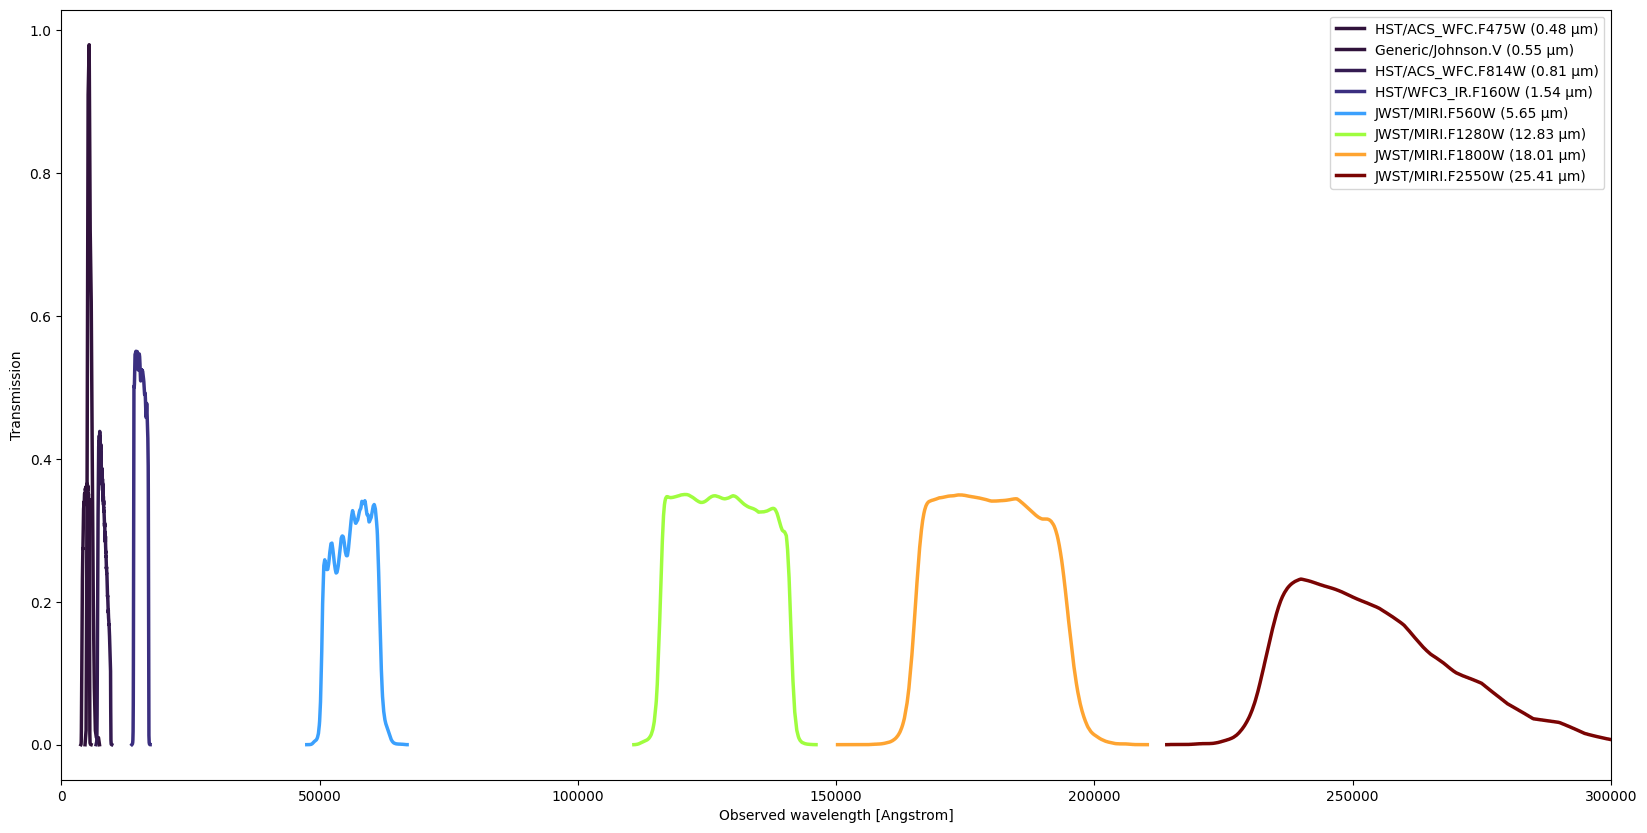

In [2]:
from astroquery.svo_fps import SvoFps
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

filter_ids = [
     "Generic/Johnson.V",  
    "HST/WFC3_IR.F160W",
    "HST/ACS_WFC.F814W",
    "HST/ACS_WFC.F475W",
    "JWST/MIRI.F1800W",
    "JWST/MIRI.F2550W",
    "JWST/MIRI.F1280W",
    "JWST/MIRI.F560W",
]

z = 2.1600

filter_data = []

for fid in filter_ids:
    print(fid)
    bp = SvoFps.get_transmission_data(fid)

    wave = np.asarray(bp["Wavelength"], dtype=float)
    trans = np.asarray(bp["Transmission"], dtype=float)

    lambda_eff = np.trapz(wave * trans, wave) / np.trapz(trans, wave)

    filter_data.append(
        {
            "filter_id": fid,
            "wave": wave,
            "trans": trans,
            "lambda_eff": lambda_eff,
        }
    )

filter_data = sorted(filter_data, key=lambda x: x["lambda_eff"])

cmap = cm.get_cmap("turbo")
norm = mcolors.Normalize(
    vmin=min(d["lambda_eff"] for d in filter_data),
    vmax=max(d["lambda_eff"] for d in filter_data),
)

fig, ax = plt.subplots(figsize=(20, 10))

for d in filter_data:
    color = cmap(norm(d["lambda_eff"]))

    ax.plot(
        d["wave"],
        d["trans"],
        color=color,
        lw=2.5,
        label=f'{d["filter_id"]} ({d["lambda_eff"]/1e4:.2f} μm)',
    )

ax.set_xlabel("Observed wavelength [Angstrom]")
ax.set_ylabel("Transmission")
ax.set_xlim(0, 300100)
ax.legend()
plt.show()

Generic/Johnson.V
HST/WFC3_IR.F160W
HST/ACS_WFC.F814W
HST/ACS_WFC.F475W
JWST/MIRI.F1800W
JWST/MIRI.F2550W


/tmp/ipykernel_1906/38133267.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lambda_eff = np.trapz(wave * trans, wave) / np.trapz(trans, wave)
/tmp/ipykernel_1906/38133267.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lambda_eff = np.trapz(wave * trans, wave) / np.trapz(trans, wave)
/tmp/ipykernel_1906/38133267.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lambda_eff = np.trapz(wave * trans, wave) / np.trapz(trans, wave)
/tmp/ipykernel_1906/38133267.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lambda_eff = np.trapz(wave * trans, wave) / np.trapz(trans, wave)
/tmp/ipykernel_1906/38133267.py:29: Depr

JWST/MIRI.F1280W
JWST/MIRI.F560W


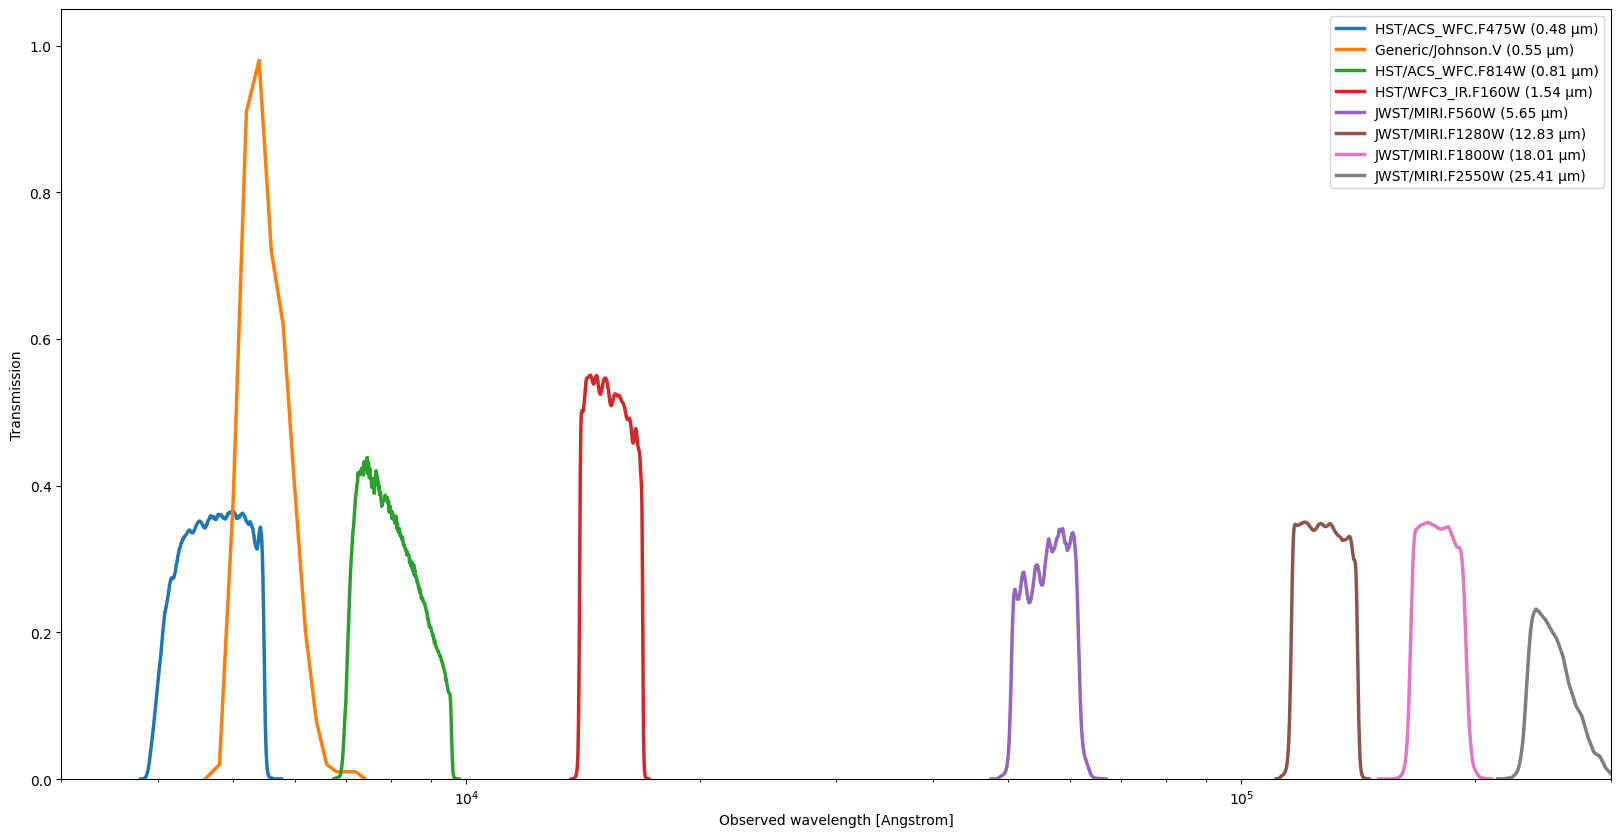

In [4]:
from astroquery.svo_fps import SvoFps
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

filter_ids = [
    "Generic/Johnson.V",
    "HST/WFC3_IR.F160W",
    "HST/ACS_WFC.F814W",
    "HST/ACS_WFC.F475W",
    "JWST/MIRI.F1800W",
    "JWST/MIRI.F2550W",
    "JWST/MIRI.F1280W",
    "JWST/MIRI.F560W",
]

z = 2.1600

filter_data = []

for fid in filter_ids:
    print(fid)
    bp = SvoFps.get_transmission_data(fid)

    wave = np.asarray(bp["Wavelength"], dtype=float)
    trans = np.asarray(bp["Transmission"], dtype=float)

    lambda_eff = np.trapz(wave * trans, wave) / np.trapz(trans, wave)

    filter_data.append(
        {
            "filter_id": fid,
            "wave": wave,
            "trans": trans,
            "lambda_eff": lambda_eff,
        }
    )

filter_data = sorted(filter_data, key=lambda x: x["lambda_eff"])

cmap = cm.get_cmap("turbo")
norm = mcolors.Normalize(
    vmin=min(d["lambda_eff"] for d in filter_data),
    vmax=max(d["lambda_eff"] for d in filter_data),
)

fig, ax = plt.subplots(figsize=(20, 10))

for d in filter_data:
    color = cmap(norm(d["lambda_eff"]))

    ax.plot(
        d["wave"],
        d["trans"],
        #color=color,
        lw=2.5,
        label=f'{d["filter_id"]} ({d["lambda_eff"]/1e4:.2f} μm)',
    )

ax.set_xscale("log")

ax.set_xlabel("Observed wavelength [Angstrom]")
ax.set_ylabel("Transmission")

ax.set_xlim(3000, 300100)
ax.set_ylim(0, 1.05)

ax.legend()
plt.show()